In [1]:
import gifba
from scipy.integrate import solve_ivp
import numpy as np
import cobra as cb
import pandas as pd
from IPython.display import clear_output
import copy
import matplotlib.pyplot as plt
from cobra import Model
import os
from pathlib import Path
import json

In [2]:
# import all files from benchmark_results
# RESULTS_DIR = Path(os.getcwd()) / "glpk_benchmark_results"
RESULTS_DIR = Path("/home/rseag/UVM/M3_Lab/giFBA/Examples/2_real_models/glpk_benchmark_results-test")

# Load all JSON files in the results directory
results = {
    file.stem: json.loads(file.read_text())
    for file in RESULTS_DIR.glob("*.json")
}
df = pd.DataFrame.from_dict(results, orient="index")

df = df.dropna(subset=['gifba_fluxes', 'dfba_fluxes'], how="all")


# # convert all numeric columns to float
# df = df.apply(pd.to_numeric, errors='ignore')


In [3]:
# save each model_names in case later is needed
model_names = df['model_names']

df.drop(columns=['model_names'], inplace=True)
df

,N_models,sum_N_rxns,sum_N_mets,vmax,km,solver_method,early_stop_window,early_stop_tol,model_solver,gifba_solve_time,...,gifba_pfba_calls,dfba_pfba_calls,dfba_status,error,status,gifba_fluxes,dfba_fluxes,dfba_success,dfba_message,dfba_termination_t
AH_BI_euro_y0_nonzeros,2,2083,1912,191.791026,0.298365,RK45,23,0.00001,glpk,11.304857,...,18,1804,dfba_complete,None,dfba_complete,"{'3OAR9M10': {'0': 0.0, '1': 0.0}, 'PC17M': {'...","{'3OAR9M10': {'0': 0.0, '1': 0.0}, 'PC17M': {'...",True,The solver successfully reached the end of the...,0.500000
AH_BI_min_med_y0_nonzeros,2,2083,1912,170.735265,0.155568,BDF,11,0.00001,glpk,11.126019,...,24,3114,dfba_complete,None,dfba_complete,"{'3OAR120': {'0': 0.0, '1': 0.0}, 'ALALEUabc':...","{'3OAR120': {'0': 0.0, '1': 0.0}, 'ALALEUabc':...",True,The solver successfully reached the end of the...,0.500000
AH_BI_min_med_y0_zero,2,2083,1912,162.975083,0.104762,BDF,6,0.00001,glpk,11.319625,...,24,1176,dfba_complete,None,dfba_complete,"{'ASAD': {'0': -0.07427128904937194, '1': -0.1...","{'ASAD': {'0': -0.00515309432247377, '1': -0.0...",True,A termination event occurred.,0.000047
AH_BI_euro_y0_zero,2,2083,1912,422.924287,0.109750,BDF,14,0.00001,glpk,11.364381,...,18,2016,dfba_complete,None,dfba_complete,"{'LPLIPAL1A181': {'0': 0.0, '1': 0.0}, 'LPLIPA...","{'LPLIPAL1A181': {'0': 0.0, '1': 0.0}, 'LPLIPA...",True,A termination event occurred.,0.001276


In [4]:
# discretize continuous variables


# min & max values (some stated in VACC_dfba.py)
vmax_min = 100
vmax_max = 1000
km_min = 0.1
km_max = 1
early_stop_window_min = 4
early_stop_window_max = 30
early_stop_tol_min = 1e-7
early_stop_tol_max = 1e-4

# details to use for the binning
# sum_N_rxns_dist        = {'bins': 3, 'spread': 'linear', 'min': df["sum_N_rxns"].min(), 'max': df["sum_N_rxns"].max(), "fmt_bins": "{:.0f}"}
# sum_N_mets_dist        = {'bins': 3, 'spread': 'linear', 'min': df["sum_N_mets"].min(), 'max': df["sum_N_mets"].max(), "fmt_bins": "{:.0f}"}
vmax_dist              = {'bins': 2, 'spread': 'log',    'min': 100,                    'max': 1000,                   "fmt_bins": "{:.0f}"}
km_dist                = {'bins': 2, 'spread': 'log',    'min': 0.1,                    'max': 1.0,                    "fmt_bins": "{:.1f}"}
early_stop_window_dist = {'bins': 3, 'spread': 'linear', 'min': 4,                      'max': 30,                     "fmt_bins": "{:.0f}"}
early_stop_tol_dist    = {'bins': 3, 'spread': 'log',    'min': 1e-7,                   'max': 1e-4,                   "fmt_bins": "{:.1e}"}

# chose bin borders based on N bins and spread
def get_bin_borders(dist):
    if dist['spread'] == 'linear':
        return np.linspace(dist['min'], dist['max'], dist['bins'] + 1)
    elif dist['spread'] == 'log':
        return np.logspace(np.log10(dist['min']), np.log10(dist['max']), dist['bins'] + 1)

def get_bin_labels(var_name, bins, fmt="{:.2g}"):
    return [var_name + r"$\in$" +f"[{fmt.format(bins[i])}, {fmt.format(bins[i+1])}]" for i in range(len(bins) - 1)]

# key_names = ["sum_N_rxns", "sum_N_mets", "vmax", "km", "early_stop_window", "early_stop_tol"]
# variable_names = [r"$N_{rxn}$", r"$N_{met}$", r"$V_{max}$", r"$K_m$", r"$N_{LR}$", r"$tol_{LR}$"]
# binning_list = [sum_N_rxns_dist, sum_N_mets_dist, vmax_dist, km_dist, early_stop_window_dist, early_stop_tol_dist]
key_names = ["vmax", "km", "early_stop_window", "early_stop_tol"]
variable_names = [r"$V_{max}$", r"$K_m$", r"$N_{LR}$", r"$tol_{LR}$"]
binning_list = [vmax_dist, km_dist, early_stop_window_dist, early_stop_tol_dist]
binning_dict = dict(zip(key_names, binning_list))

for i, key in enumerate(key_names):
    dist = binning_dict[key]
    bins = get_bin_borders(dist)
    labels = get_bin_labels(variable_names[i], bins, dist["fmt_bins"])
    df[f"{key}_binned"] = pd.cut(df[key], bins=bins, labels=labels, include_lowest=True)

key_to_variable_names = dict(zip(key_names, variable_names))
key_to_variable_names.update({"N_models": r"$N_{models}$", "solver_method": "Solver Method"})

df

,N_models,sum_N_rxns,sum_N_mets,vmax,km,solver_method,early_stop_window,early_stop_tol,model_solver,gifba_solve_time,...,status,gifba_fluxes,dfba_fluxes,dfba_success,dfba_message,dfba_termination_t,vmax_binned,km_binned,early_stop_window_binned,early_stop_tol_binned
AH_BI_euro_y0_nonzeros,2,2083,1912,191.791026,0.298365,RK45,23,0.00001,glpk,11.304857,...,dfba_complete,"{'3OAR9M10': {'0': 0.0, '1': 0.0}, 'PC17M': {'...","{'3OAR9M10': {'0': 0.0, '1': 0.0}, 'PC17M': {'...",True,The solver successfully reached the end of the...,0.500000,"$V_{max}$$\in$[100, 316]","$K_m$$\in$[0.1, 0.3]","$N_{LR}$$\in$[21, 30]","$tol_{LR}$$\in$[1.0e-06, 1.0e-05]"
AH_BI_min_med_y0_nonzeros,2,2083,1912,170.735265,0.155568,BDF,11,0.00001,glpk,11.126019,...,dfba_complete,"{'3OAR120': {'0': 0.0, '1': 0.0}, 'ALALEUabc':...","{'3OAR120': {'0': 0.0, '1': 0.0}, 'ALALEUabc':...",True,The solver successfully reached the end of the...,0.500000,"$V_{max}$$\in$[100, 316]","$K_m$$\in$[0.1, 0.3]","$N_{LR}$$\in$[4, 13]","$tol_{LR}$$\in$[1.0e-06, 1.0e-05]"
AH_BI_min_med_y0_zero,2,2083,1912,162.975083,0.104762,BDF,6,0.00001,glpk,11.319625,...,dfba_complete,"{'ASAD': {'0': -0.07427128904937194, '1': -0.1...","{'ASAD': {'0': -0.00515309432247377, '1': -0.0...",True,A termination event occurred.,0.000047,"$V_{max}$$\in$[100, 316]","$K_m$$\in$[0.1, 0.3]","$N_{LR}$$\in$[4, 13]","$tol_{LR}$$\in$[1.0e-06, 1.0e-05]"
AH_BI_euro_y0_zero,2,2083,1912,422.924287,0.109750,BDF,14,0.00001,glpk,11.364381,...,dfba_complete,"{'LPLIPAL1A181': {'0': 0.0, '1': 0.0}, 'LPLIPA...","{'LPLIPAL1A181': {'0': 0.0, '1': 0.0}, 'LPLIPA...",True,A termination event occurred.,0.001276,"$V_{max}$$\in$[316, 1000]","$K_m$$\in$[0.1, 0.3]","$N_{LR}$$\in$[13, 21]","$tol_{LR}$$\in$[1.0e-06, 1.0e-05]"


In [5]:
# # parse gifba and dfba into separate dfs
# gifba_df = df[["N_models", "sum_N_rxns_binned", "sum_N_mets_binned", "gifba_solve_time", "gifba_pfba_calls"]].copy()
# dfba_df = df[["N_models", "sum_N_rxns_binned", "sum_N_mets_binned", "vmax_binned", "km_binned", "solver_method", "early_stop_window_binned", "early_stop_tol_binned", "dfba_solve_time", "dfba_pfba_calls"]].copy()
gifba_df = df[["N_models", "sum_N_rxns", "sum_N_mets", "gifba_solve_time", "gifba_pfba_calls"]].copy()
dfba_df = df[["N_models", "sum_N_rxns", "sum_N_mets", "vmax_binned", "km_binned", "solver_method", "early_stop_window_binned", "early_stop_tol_binned", "dfba_solve_time", "dfba_pfba_calls"]].copy()


gifba_df.rename(columns={
    "gifba_solve_time": "solve_time",
    "gifba_pfba_calls": "pfba_calls"
}, inplace=True)
dfba_df.rename(columns={
    "dfba_solve_time": "solve_time",
    "dfba_pfba_calls": "pfba_calls"
}, inplace=True)

print("giFBA: \n", gifba_df.head())
print("dFBA: \n", dfba_df.head())

giFBA: 
                            N_models  sum_N_rxns  sum_N_mets  solve_time  \
AH_BI_euro_y0_nonzeros            2        2083        1912   11.304857   
AH_BI_min_med_y0_nonzeros         2        2083        1912   11.126019   
AH_BI_min_med_y0_zero             2        2083        1912   11.319625   
AH_BI_euro_y0_zero                2        2083        1912   11.364381   

                           pfba_calls  
AH_BI_euro_y0_nonzeros             18  
AH_BI_min_med_y0_nonzeros          24  
AH_BI_min_med_y0_zero              24  
AH_BI_euro_y0_zero                 18  
dFBA: 
                            N_models  sum_N_rxns  sum_N_mets  \
AH_BI_euro_y0_nonzeros            2        2083        1912   
AH_BI_min_med_y0_nonzeros         2        2083        1912   
AH_BI_min_med_y0_zero             2        2083        1912   
AH_BI_euro_y0_zero                2        2083        1912   

                                         vmax_binned             km_binned  \
AH_BI_euro_y0

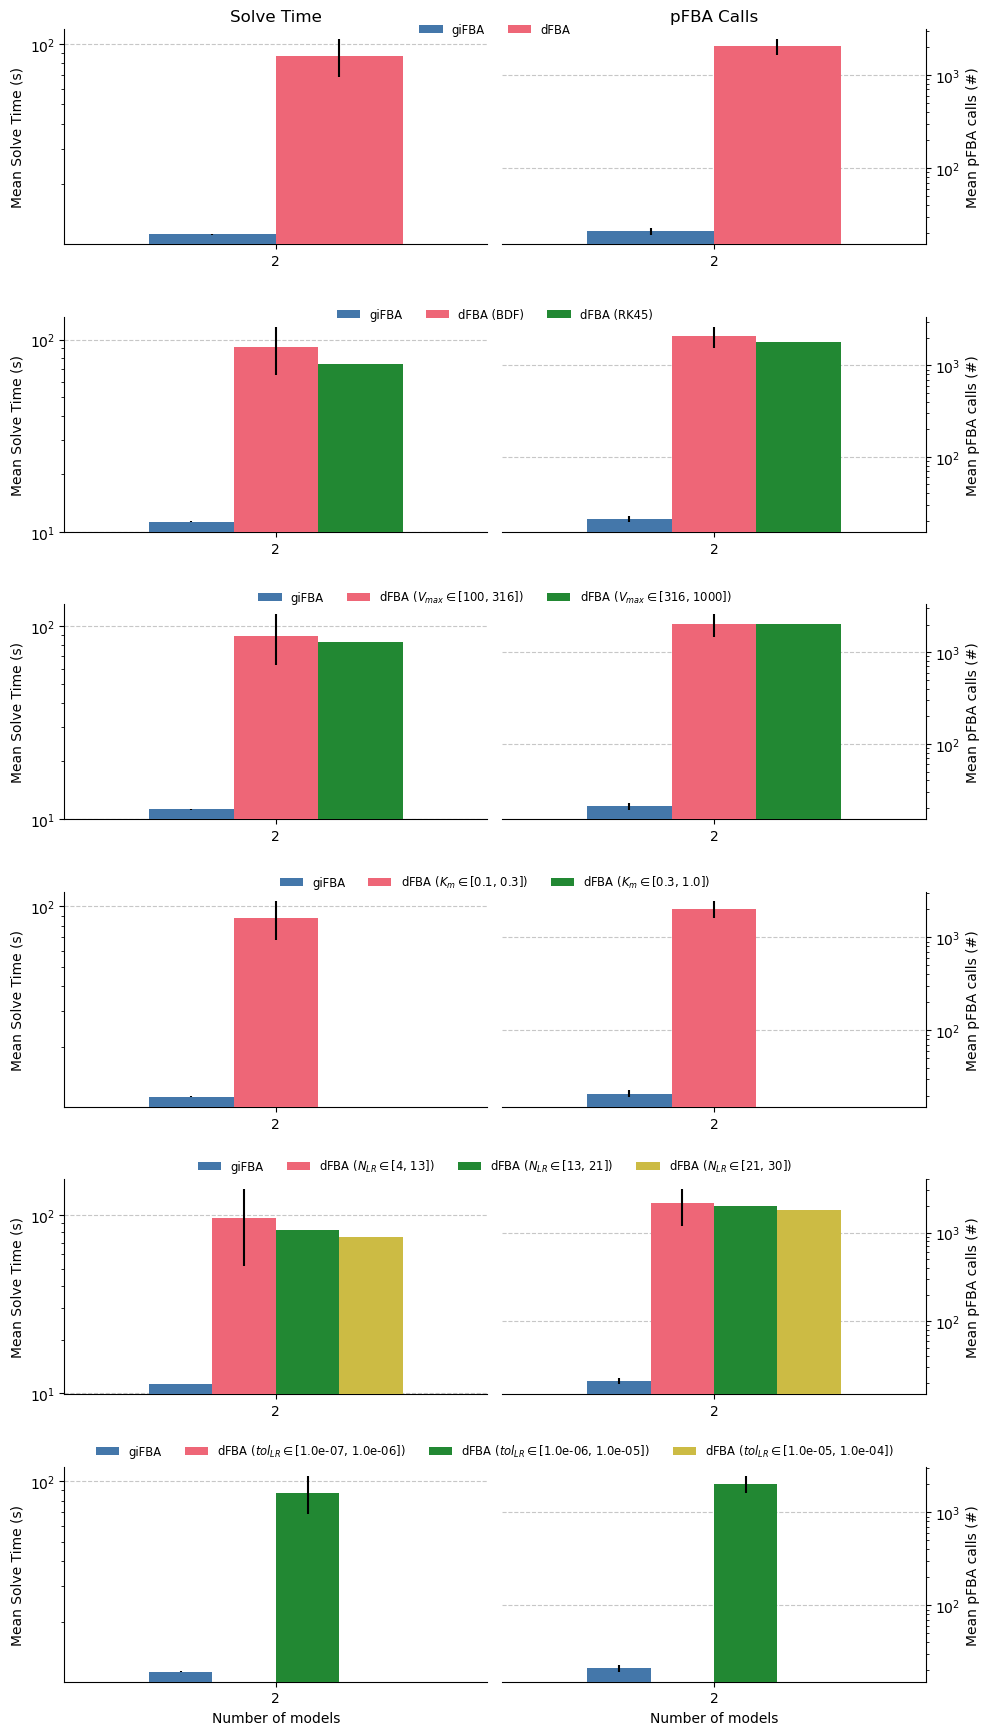

In [6]:
import matplotlib as mpl
from matplotlib.transforms import Bbox
import tol_colors as tol


mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=tol.bright)
      
Y_SCALE = "log"

vars_eval = [["N_models"],
             ["N_models", "solver_method"],
             ["N_models", "vmax_binned"],
             ["N_models", "km_binned"],
             ["N_models", "early_stop_window_binned"],
             ["N_models", "early_stop_tol_binned"]]


fig, axs = plt.subplots(6, 2, figsize=(10, 18))
axs = axs.flatten()


def plot_subgrouped(gifba_results, dfba_results, groupby_cols, row, legend_labels, axs):
    y_labels=["Mean Solve Time (s)", "Mean pFBA calls (#)"]

    for i, value_col in enumerate(["solve_time", "pfba_calls"]):
        ax = axs[row * 2 + i]
        y_label = y_labels[i]
        dfba_means = dfba_results.groupby(groupby_cols, observed=False)[value_col].mean()
        dfba_sem = dfba_results.groupby(groupby_cols, observed=False)[value_col].sem()
        gifba_means = gifba_results.groupby(groupby_cols[0], observed=False)[value_col].mean()
        gifba_sem = gifba_results.groupby(groupby_cols[0], observed=False)[value_col].sem()

        if len(groupby_cols) != 1:
            dfba_means_unstacked = dfba_means.unstack(level=groupby_cols[1])
            dfba_sem_unstacked = dfba_sem.unstack(level=groupby_cols[1])
        else:
            dfba_means_unstacked = dfba_means.to_frame(name=legend_labels[1])
            dfba_sem_unstacked = dfba_sem.to_frame(name=legend_labels[1])

        if len(groupby_cols) > 1:
            dfba_means_unstacked.columns = [f"{legend_labels[1]} ({col})" for col in dfba_means_unstacked.columns]
            dfba_sem_unstacked.columns = [f"{legend_labels[1]} ({col})" for col in dfba_sem_unstacked.columns]

        combined_means = pd.concat([gifba_means.rename(legend_labels[0]), dfba_means_unstacked], axis=1)
        combined_sems = pd.concat([gifba_sem.rename(legend_labels[0]), dfba_sem_unstacked], axis=1)

        combined_means.plot(kind="bar", yerr=combined_sems, ax=ax, legend=False, width=0.75, zorder=3)

        # annotate
        ax.set_yscale(Y_SCALE)
        ax.grid(axis="y", linestyle="--", alpha=0.7, zorder=0)
        if row == 5:
            ax.set_xlabel("Number of models")
        else: ax.set_xlabel("")
        ax.tick_params(labelbottom=True, labelrotation=0)
        ax.set_ylabel(y_label)
        if i == 1:
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(True)
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
        else:
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(True)
        ax.spines['top'].set_visible(False)

        if row == 0:
            if i == 0:
                ax.set_title("Solve Time")
            else:
                ax.set_title("pFBA Calls")




# plot each of these groupings
for row, groupby_cols in enumerate(vars_eval):
    plot_subgrouped(gifba_df, 
                    dfba_df, 
                    groupby_cols, 
                    row, 
                    ["giFBA", "dFBA"], 
                    axs)

plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=3.5)

for row in range(6):
    ax_left = axs[row * 2]
    ax_right = axs[row * 2 + 1]
    
    handles, labels = ax_left.get_legend_handles_labels()
    if handles:
        bbox_left = ax_left.get_position()
        bbox_right = ax_right.get_position()
        
        # Merge bounding boxes of both subplots in the row
        combined_bbox = Bbox.union([bbox_left, bbox_right])
        
        fig.legend(
            handles, 
            labels, 
            loc="lower center", 
            bbox_to_anchor=(combined_bbox.x0 + combined_bbox.width / 2, combined_bbox.y1*0.99),
            bbox_transform=fig.transFigure,
            ncol=len(handles),
            frameon=False,
            fontsize="small"
        )

In [7]:
# show counts per binning for each variable
for var in vars_eval:
    gifba_counts_per_N_models = gifba_df.groupby("N_models", observed=False).size()
    if len(var) > 1:
        counts = dfba_df.groupby(var, observed=False).size().unstack(level=var[1])
        if len(counts.columns) == 2:
            ordinal_label_suffixes = ["Low", "High"]
        else:
            ordinal_label_suffixes = ["Low", "Medium", "High"]
        if "$\in$" in counts.columns[0]:
            new_cols = []
            for i, col in enumerate(counts.columns):
                new_cols.append(col.split("$\in$")[0].replace("$", "").replace("{", "").replace("}", "") + " " +ordinal_label_suffixes[i])
            counts.columns = new_cols

    else:
        counts = dfba_df.groupby(var, observed=False).size()

    # gifba as column in counts
    if type(counts) == pd.Series:
        counts = counts.to_frame(name="dFBA")
    counts["gifba"] = gifba_counts_per_N_models


    print(f"Counts for {var}:")
    print(counts)
    print("\n")

Counts for ['N_models']:
          dFBA  gifba
N_models             
2            4      4


Counts for ['N_models', 'solver_method']:
solver_method  BDF  RK45  gifba
N_models                       
2                3     1      4


Counts for ['N_models', 'vmax_binned']:
          V_max Low  V_max High  gifba
N_models                              
2                 3           1      4


Counts for ['N_models', 'km_binned']:
          K_m Low  K_m High  gifba
N_models                          
2               4         0      4


Counts for ['N_models', 'early_stop_window_binned']:
          N_LR Low  N_LR Medium  N_LR High  gifba
N_models                                         
2                2            1          1      4


Counts for ['N_models', 'early_stop_tol_binned']:
          tol_LR Low  tol_LR Medium  tol_LR High  gifba
N_models                                               
2                  0              4            0      4




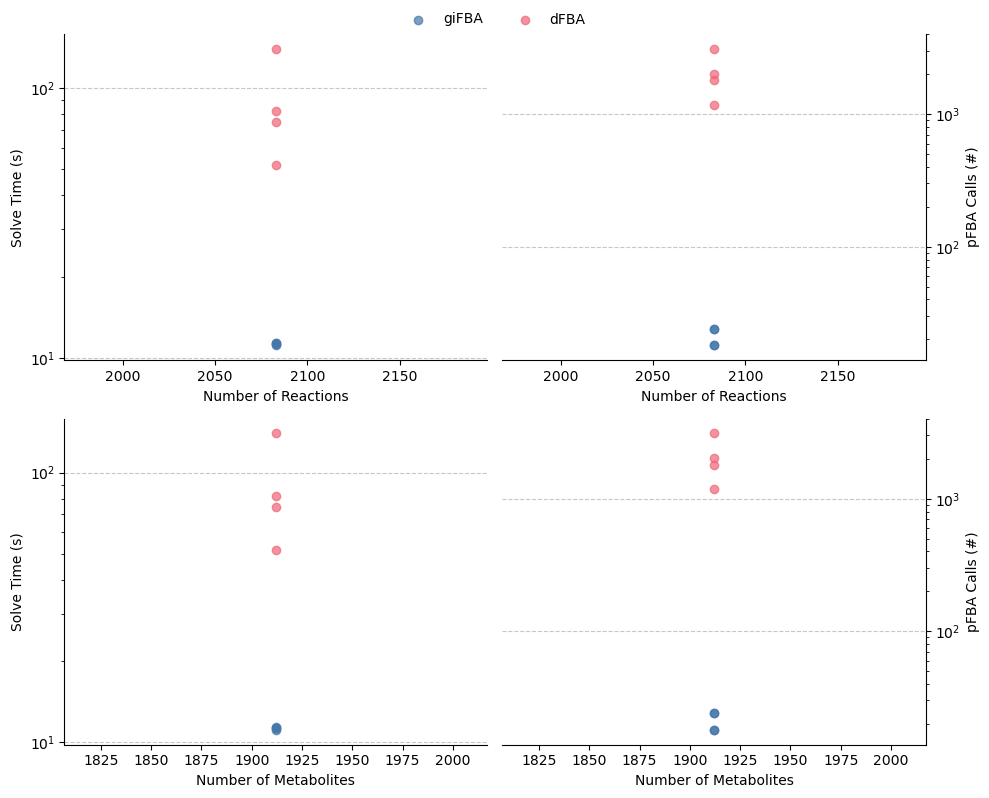

In [8]:
# compare N_mets and N_rxns to runtime and pFBA calls

x_vars = ["sum_N_rxns", "sum_N_mets"]
y_vars = ["solve_time", "pfba_calls"]
x_vars_ordinal = ["Number of Reactions", "Number of Metabolites"]
y_vars_ordinal = ["Solve Time (s)", "pFBA Calls (#)"]

fig, axs = plt.subplots(len(x_vars), len(y_vars), figsize=(10, 8))

for i, x_var in enumerate(x_vars):
    for j, y_var in enumerate(y_vars):
        ax = axs[i, j]
        ax.scatter(gifba_df[x_var], gifba_df[y_var], label="giFBA", alpha=0.7)
        ax.scatter(dfba_df[x_var], dfba_df[y_var], label="dFBA", alpha=0.7)
        ax.set_xlabel(x_vars_ordinal[i])
        ax.set_ylabel(y_vars_ordinal[j])
        ax.set_yscale(Y_SCALE)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        # Move the y-axis to the right side for the second col
        if j == 1:
            ax.spines['left'].set_visible(False)
            ax.spines['right'].set_visible(True)
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
        else:
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(True)
        ax.spines['top'].set_visible(False)

# add legend to top of the figure
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.98])

In [9]:
# evaluate accuracy of dFBA vs giFBA fluxes

def parse_simulation_series(s: pd.Series) -> pd.DataFrame:
    """Parses a Series where each entry is a nested dict:

    {rxn_id: {org_idx: flux}} into a flattened DataFrame with columns
    'f"{rxn_id}___{org_idx}"'.
    """
    flattened_rows = []

    for sim_id, sim_data in s.items():
        row_dict = {}
        if isinstance(sim_data, dict):
            for rxn_id, org_dict in sim_data.items():
                if isinstance(org_dict, dict):
                    for org_idx, flux in org_dict.items():
                        col_name = f"{rxn_id}___{org_idx}"
                        row_dict[col_name] = flux
        flattened_rows.append(row_dict)

    # Convert to DataFrame using the original Series index
    # Missing reaction-organism pairs naturally default to NaN
    df = pd.DataFrame(flattened_rows, index=s.index)

    return df

gifba_fluxes_df = parse_simulation_series(df['gifba_fluxes'])
dfba_fluxes_df = parse_simulation_series(df['dfba_fluxes'])

all_nan_cols_gifba = gifba_fluxes_df.columns[gifba_fluxes_df.isna().all()].tolist()
all_nan_cols_dfba  =  dfba_fluxes_df.columns[dfba_fluxes_df.isna().all()].tolist()
all_zero_cols_gifba = gifba_fluxes_df.columns[(gifba_fluxes_df == 0).all()].tolist()
all_zero_cols_dfba = dfba_fluxes_df.columns[(dfba_fluxes_df == 0).all()].tolist()
all_nan_or_zero_cols_gifba = gifba_fluxes_df.columns[(gifba_fluxes_df.fillna(0) == 0).all()].tolist()
all_nan_or_zero_cols_dfba = dfba_fluxes_df.columns[(dfba_fluxes_df.fillna(0) == 0).all()].tolist()

all_nan_or_zero_cols_both = set(all_nan_or_zero_cols_gifba).intersection(set(all_nan_or_zero_cols_dfba))

print(f"Columns with all NaN in giFBA: {len(all_nan_cols_gifba)}")
print(f"Columns with all NaN in  dFBA: {len(all_nan_cols_dfba)}")
print()
print(f"Columns with all Zeros in giFBA: {len(all_zero_cols_gifba)}")
print(f"Columns with all Zeros in  dFBA: {len(all_zero_cols_dfba)}")
print()
print(f"Columns with all NaN/zero in giFBA: {len(all_nan_or_zero_cols_gifba)}")
print(f" Columns with all NaN/zero in dFBA: {len(all_nan_or_zero_cols_dfba)}")
print(f" Columns with all NaN/zero in both: {len(all_nan_or_zero_cols_both)}")
print()

# select only the common columns for comparison
gifba_fluxes_df_common = gifba_fluxes_df.drop(columns=all_nan_or_zero_cols_both, errors='ignore')
dfba_fluxes_df_common = dfba_fluxes_df.drop(columns=all_nan_or_zero_cols_both, errors='ignore')

# re-index and sort columns to ensure they match
gifba_fluxes_df_common = gifba_fluxes_df_common.reindex(sorted(gifba_fluxes_df_common.columns), axis=1)
dfba_fluxes_df_common = dfba_fluxes_df_common.reindex(sorted(dfba_fluxes_df_common.columns), axis=1)

print(f"Shape of giFBA fluxes DataFrame (common columns): {gifba_fluxes_df_common.shape}")
print(f" Shape of dFBA fluxes DataFrame (common columns): {dfba_fluxes_df_common.shape}")

Columns with all NaN in giFBA: 0
Columns with all NaN in  dFBA: 0

Columns with all Zeros in giFBA: 2190
Columns with all Zeros in  dFBA: 2176

Columns with all NaN/zero in giFBA: 2190
 Columns with all NaN/zero in dFBA: 2176
 Columns with all NaN/zero in both: 2176

Shape of giFBA fluxes DataFrame (common columns): (4, 612)
 Shape of dFBA fluxes DataFrame (common columns): (4, 612)


In [10]:
# ensure order of columns and indexes match
#show before sorting
print("Before sorting:")
print("giFBA: \n", gifba_fluxes_df_common.iloc[:5, :5])
print("DFBA: \n", dfba_fluxes_df_common.iloc[:5, :5])

gifba_fluxes_df_common = gifba_fluxes_df_common.sort_index(axis=0).sort_index(axis=1)
dfba_fluxes_df_common = dfba_fluxes_df_common.sort_index(axis=0).sort_index(axis=1)

# show after sorting
print("After sorting:")
print("giFBA: \n", gifba_fluxes_df_common.iloc[:5, :5])
print("DFBA: \n", dfba_fluxes_df_common.iloc[:5, :5])

Before sorting:
giFBA: 
                            12PPDSDH___1  26DAPLLAT___1  4HTHDR___0  \
AH_BI_euro_y0_nonzeros         0.878582      -0.001454    0.000000   
AH_BI_min_med_y0_nonzeros      0.000000      -0.009158    0.028445   
AH_BI_min_med_y0_zero          0.000000      -0.009158    0.028445   
AH_BI_euro_y0_zero             0.878582      -0.001454    0.000000   

                           4HTHDR___1  4HTHDS___0  
AH_BI_euro_y0_nonzeros       0.001454    0.000000  
AH_BI_min_med_y0_nonzeros    0.009158    0.028445  
AH_BI_min_med_y0_zero        0.009158    0.028445  
AH_BI_euro_y0_zero           0.001454    0.000000  
DFBA: 
                            12PPDSDH___1  26DAPLLAT___1  4HTHDR___0  \
AH_BI_euro_y0_nonzeros         0.865499      -0.001432    0.020976   
AH_BI_min_med_y0_nonzeros      0.000000      -0.009198    0.000000   
AH_BI_min_med_y0_zero          0.000000      -0.000424    0.000945   
AH_BI_euro_y0_zero             4.357552      -0.007148    0.000000   

     

N of biomass Ex columns (before filtering): 4
N of biomass Ex columns (after  filtering): 2
Biomass exchange flux columns: ['EX_biomass(e)_1___0', 'EX_biomass(e)_2___1']


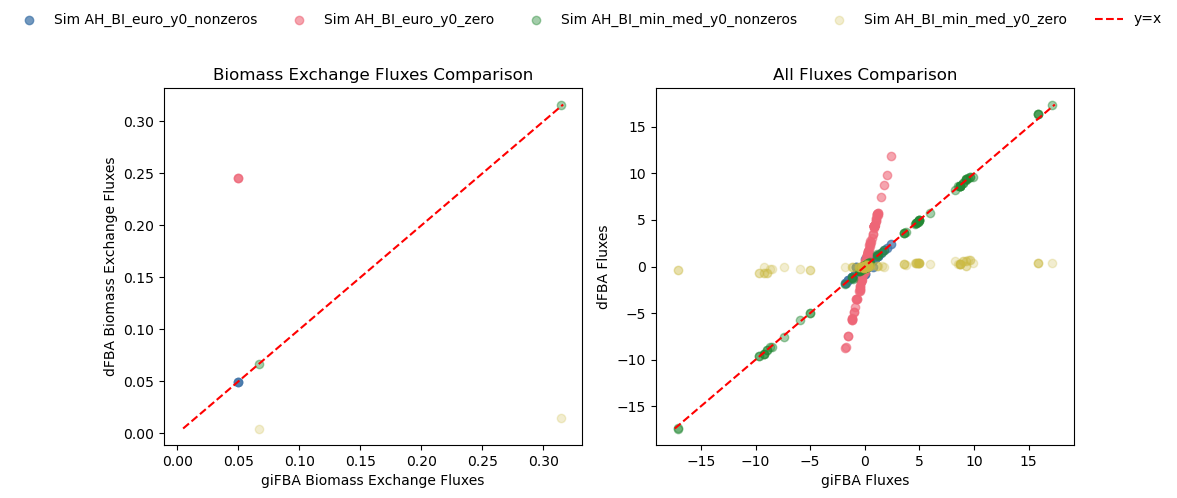

In [11]:
# parse and compare biomass EXchange fluxes
biomass_ex_cols_pre = [col for col in gifba_fluxes_df.columns if col.startswith("EX_biomass(e)")]
biomass_ex_cols = [col for col in gifba_fluxes_df_common.columns if col.startswith("EX_biomass(e)")]
print(f"N of biomass Ex columns (before filtering): {len(biomass_ex_cols_pre)}")
print(f"N of biomass Ex columns (after  filtering): {len(biomass_ex_cols)}")
print("Biomass exchange flux columns:", biomass_ex_cols)

n_rows_bio, n_cols_bio = gifba_fluxes_df_common[biomass_ex_cols].shape
row_indices_bio = np.repeat(np.arange(n_rows_bio), n_cols_bio)

n_rows_all, n_cols_all = gifba_fluxes_df_common.shape
row_indices_all = np.repeat(np.arange(n_rows_all), n_cols_all)

# plots comparison w/ xaxis=gifba, yaxis=dfba, compare all bm ex fluxes
min_val_bio = min(gifba_fluxes_df_common[biomass_ex_cols].min().min(), dfba_fluxes_df_common[biomass_ex_cols].min().min())
max_val_bio = max(gifba_fluxes_df_common[biomass_ex_cols].max().max(), dfba_fluxes_df_common[biomass_ex_cols].max().max())
min_val = min(gifba_fluxes_df_common.min().min(), dfba_fluxes_df_common.min().min())
max_val = max(gifba_fluxes_df_common.max().max(), dfba_fluxes_df_common.max().max())

if gifba_fluxes_df_common.shape[0] < 5:
    colors = tol.bright[:len(gifba_fluxes_df_common.index)]
else:
    colors = [tol.bright[0] for _ in range(len(gifba_fluxes_df_common.index))] 



fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for (k, df_index), color in zip(
    enumerate(gifba_fluxes_df_common.index), colors):
    if gifba_fluxes_df_common.shape[0] < 5:
        alpha = -1/6 * k + 0.75
        label = f"Sim {df_index}"
    else:
        alpha = 0.5
        label = ""
    axs[0].scatter(gifba_fluxes_df_common.loc[df_index, biomass_ex_cols].values.flatten(),
                dfba_fluxes_df_common.loc[df_index, biomass_ex_cols].values.flatten(),
                alpha=alpha,
                c=color,
                label=label)

    axs[1].scatter(gifba_fluxes_df_common.loc[df_index, :].values.flatten(),
                dfba_fluxes_df_common.loc[df_index, :].values.flatten(),
                alpha=alpha,
                c=color,
                label=label)


axs[0].plot([min_val_bio, max_val_bio], [min_val_bio, max_val_bio], 'r--', label="y=x")
axs[1].plot([min_val, max_val], [min_val, max_val], 'r--', label="y=x")

axs[0].set_xlabel("giFBA Biomass Exchange Fluxes")
axs[0].set_ylabel("dFBA Biomass Exchange Fluxes")
axs[0].set_title("Biomass Exchange Fluxes Comparison")

axs[1].set_xlabel("giFBA Fluxes")
axs[1].set_ylabel("dFBA Fluxes")
axs[1].set_title("All Fluxes Comparison")


handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=(len(gifba_fluxes_df_common.index)+1), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.9])